# 기본모델 + 조기종료

사용 디바이스: cuda
총 데이터 수: 2199

Train: 1583 | Val: 176 | Test: 440


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5606.57it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



학습 시작
Epoch  1 | Train Acc 54.6% (F1 0.5044) | Val Acc 75.0% (F1 0.7474) | Test Acc 77.7% (F1 0.7758)
Epoch  2 | Train Acc 77.8% (F1 0.7775) | Val Acc 79.5% (F1 0.7922) | Test Acc 82.0% (F1 0.8180)
Epoch  3 | Train Acc 86.5% (F1 0.8654) | Val Acc 81.8% (F1 0.8173) | Test Acc 85.0% (F1 0.8493)
Epoch  4 | Train Acc 92.2% (F1 0.9216) | Val Acc 80.1% (F1 0.8010) | Test Acc 85.2% (F1 0.8522)
Epoch  5 | Train Acc 94.4% (F1 0.9438) | Val Acc 81.8% (F1 0.8180) | Test Acc 83.9% (F1 0.8383)
Epoch  6 | Train Acc 96.4% (F1 0.9640) | Val Acc 82.4% (F1 0.8237) | Test Acc 84.8% (F1 0.8476)
Epoch  7 | Train Acc 96.7% (F1 0.9671) | Val Acc 80.7% (F1 0.8062) | Test Acc 83.6% (F1 0.8360)
Epoch  8 | Train Acc 98.7% (F1 0.9867) | Val Acc 81.8% (F1 0.8182) | Test Acc 85.7% (F1 0.8568)

⏹ Early Stopping at epoch 8 (val_loss가 5번 연속 개선되지 않음)
✅ 최적 모델 복원 완료 (Best Val Loss: 0.4578)

✨ 최종 Test Acc: 85.0% | Test F1: 0.8493 ✨

─── 멀티모달 fusion용 256차원 특징 추출 ───


특징 추출: 100%|██████████| 138/138 [00:02<00:00, 60.24it/s]


✅ 텍스트 모달 특징 벡터 저장 완료 (text_features_256.pkl)
추출 완료! X_text shape: torch.Size([2199, 256])


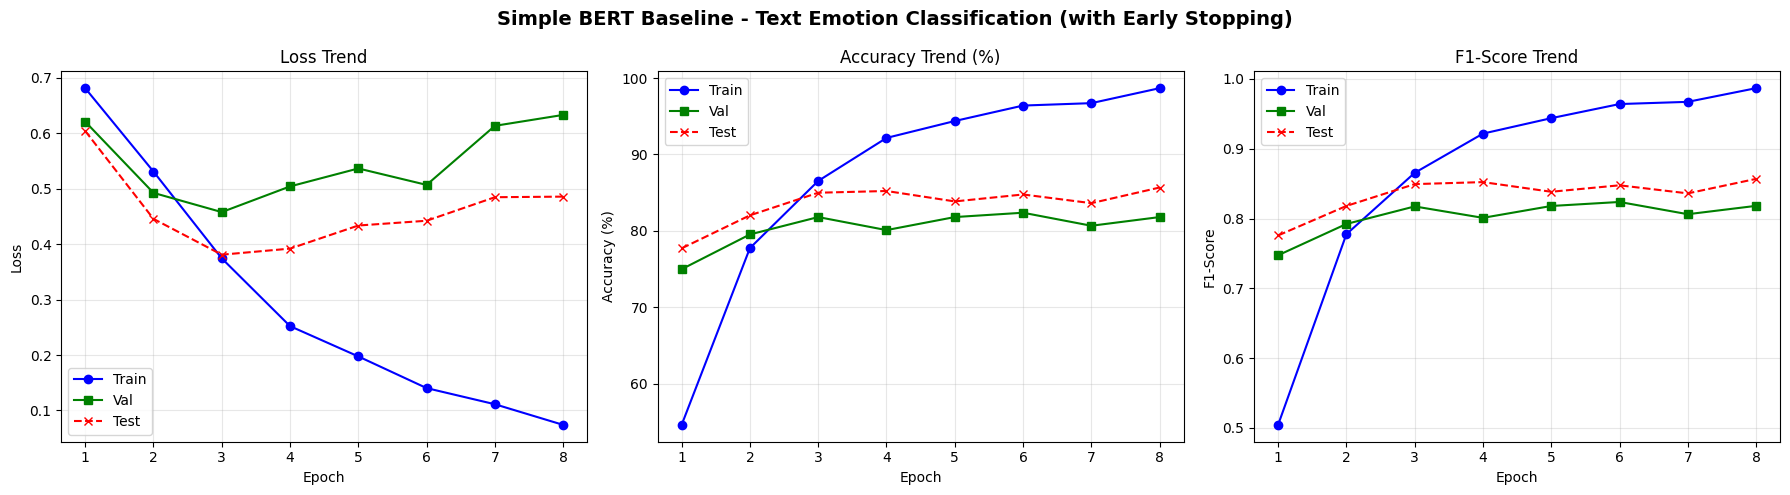

In [2]:
# 기본모델 + 조기종료
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertModel
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")


# 1. 데이터 로드
text_df = pd.read_csv('mosi_text_metadata.csv')
text_df = text_df.dropna(subset=['text', 'label'])
print(f"총 데이터 수: {len(text_df)}")

texts = text_df['text'].tolist()
labels = text_df['label'].tolist()

# Train / Test 분할
tr_texts, te_texts, tr_labels, te_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)
# val 분할
tr_texts, val_texts, tr_labels, val_labels = train_test_split(
    tr_texts, tr_labels, test_size=0.1, random_state=42, stratify=tr_labels
)
print(f"\nTrain: {len(tr_texts)} | Val: {len(val_texts)} | Test: {len(te_texts)}")


# 2. 데이터셋
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
MAX_TEXT_LEN = 50
BATCH_SIZE   = 16

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_loader = DataLoader(TextDataset(tr_texts, tr_labels, tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TextDataset(te_texts, te_labels, tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(TextDataset(val_texts, val_labels, tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=False)

# 3. 모델:순수 BERT + projection + 분류기
class SimpleBERTClassifier(nn.Module):
    def __init__(self, num_classes=2, proj_dim=256):
        super().__init__()
        self.bert       = BertModel.from_pretrained('bert-base-uncased')
        self.dropout    = nn.Dropout(0.3)
        self.projection = nn.Linear(768, proj_dim)   # 멀티모달 fusion용 256차원
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, input_ids, attention_mask, return_features=False):
        outputs  = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled   = outputs.pooler_output                        # [B, 768]
        features = self.projection(self.dropout(pooled))        # [B, 256]
        logits   = self.classifier(features)

        if return_features:
            return features
        return logits


# 4. 학습 설정 - Adam 단일 lr
NUM_EPOCHS  = 15
NUM_CLASSES = 2

model     = SimpleBERTClassifier(num_classes=NUM_CLASSES).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()


# 5. 학습 루프
def run_epoch(model, loader, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_targets = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch   = batch['label'].to(device)

            logits = model(input_ids, attention_mask)
            loss   = criterion(logits, labels_batch)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            preds = logits.argmax(1)
            total_loss += loss.item() * labels_batch.size(0)
            correct    += (preds == labels_batch).sum().item()
            total      += labels_batch.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels_batch.cpu().numpy())

    return total_loss / total, correct / total * 100, f1_score(all_targets, all_preds, average='macro')

history = {k: [] for k in ['train_loss', 'val_loss', 'test_loss',
                           'train_acc',  'val_acc',  'test_acc',
                           'train_f1',   'val_f1',   'test_f1']}

# ==========================================
# [추가] Early Stopping 설정
# ==========================================
best_val_loss = float('inf')
patience = 5       # 2 에포크 동안 val_loss가 안 떨어지면 조기 종료
patience_count = 0
best_state = None     # 가장 좋았을 때의 모델 가중치를 저장할 변수

print("\n학습 시작")
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = run_epoch(model, train_loader, optimizer, train=True)
    va_loss, va_acc, va_f1 = run_epoch(model, val_loader,  train=False)
    te_loss, te_acc, te_f1 = run_epoch(model, test_loader,  train=False)

    for k, v in zip(['train_loss','val_loss','test_loss',
                     'train_acc','val_acc','test_acc',
                     'train_f1','val_f1','test_f1'],
                    [tr_loss, va_loss, te_loss,
                     tr_acc, va_acc, te_acc,
                     tr_f1, va_f1, te_f1]):
        history[k].append(v)

    print(f"Epoch {epoch:2d} | "
          f"Train Acc {tr_acc:.1f}% (F1 {tr_f1:.4f}) | "
          f"Val Acc {va_acc:.1f}% (F1 {va_f1:.4f}) | "
          f"Test Acc {te_acc:.1f}% (F1 {te_f1:.4f})")

    # ==========================================
    # [추가] Early Stopping 체크 로직
    # ==========================================
    if va_loss < best_val_loss:
        best_val_loss = va_loss
        patience_count = 0
        # 최고 성능일 때 모델 가중치 복사해두기
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_count += 1
        if patience_count >= patience:
            print(f"\n⏹ Early Stopping at epoch {epoch} (val_loss가 {patience}번 연속 개선되지 않음)")
            break

# ==========================================
# [추가] 최적 가중치 복원 및 최종 테스트 평가
# ==========================================
if best_state:
    model.load_state_dict(best_state)
    print(f"✅ 최적 모델 복원 완료 (Best Val Loss: {best_val_loss:.4f})")

# 조기 종료 시 가장 좋았던 모델로 Test 평가 다시 진행
final_te_loss, final_te_acc, final_te_f1 = run_epoch(model, test_loader, train=False)
print(f"\n✨ 최종 Test Acc: {final_te_acc:.1f}% | Test F1: {final_te_f1:.4f} ✨")


# 6. 멀티모달 fusion용 256차원 특징 추출 및 저장
print("\n─── 멀티모달 fusion용 256차원 특징 추출 ───")
all_dataset = TextDataset(texts, labels, tokenizer, MAX_TEXT_LEN)
all_loader  = DataLoader(all_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
all_features, all_labels_out = [], []
with torch.no_grad():
    for batch in tqdm(all_loader, desc="특징 추출"):
        feats = model(batch['input_ids'].to(device),
                      batch['attention_mask'].to(device),
                      return_features=True)
        all_features.append(feats.cpu())
        all_labels_out.append(batch['label'])

X_text = torch.cat(all_features, dim=0)
y_text = torch.cat(all_labels_out, dim=0)

torch.save({'features': X_text, 'labels': y_text}, 'text_features_256(basic+earlystop).pkl')
print("✅ 텍스트 모달 특징 벡터 저장 완료 (text_features_256.pkl)")
print(f"추출 완료! X_text shape: {X_text.shape}")  # [2199, 256]


# ──────────────────────────────────────────────
# 7. 시각화
# ──────────────────────────────────────────────
# [수정] 조기 종료로 인해 전체 epoch를 다 못 채울 수 있으므로 실제 훈련한 길이로 변경
actual_epochs = len(history['train_loss'])
epochs = range(1, actual_epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs, history['val_loss'],   'g-s', label='Val')
axes[0].plot(epochs, history['test_loss'],  'r--x', label='Test')
axes[0].set_title('Loss Trend'); axes[0].set_ylabel('Loss')

axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train')
axes[1].plot(epochs, history['val_acc'],   'g-s', label='Val')
axes[1].plot(epochs, history['test_acc'],  'r--x', label='Test')
axes[1].set_title('Accuracy Trend (%)'); axes[1].set_ylabel('Accuracy (%)')

axes[2].plot(epochs, history['train_f1'], 'b-o', label='Train')
axes[2].plot(epochs, history['val_f1'],   'g-s', label='Val')
axes[2].plot(epochs, history['test_f1'],  'r--x', label='Test')
axes[2].set_title('F1-Score Trend'); axes[2].set_ylabel('F1-Score')

for ax in axes:
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Simple BERT Baseline - Text Emotion Classification (with Early Stopping)',
             fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

#  증강 + 동결6 + 조기종료

[nltk_data] Downloading package wordnet to
[nltk_data]     /home/dltndus0628/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/dltndus0628/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/dltndus0628/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/dltndus0628/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to
[nltk_data]     /home/dltndus0628/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


사용 디바이스: cuda
결측치 제거 전: 2199
결측치 제거 후: 2199
레이블 분포:
label
0    1119
1    1080
Name: count, dtype: int64

증강 전 Train: 1583 | Val: 176 | Test: 440

데이터 증강 진행 중 (Train 셋에만 적용)...
증강 후 Train 데이터 수: 3166


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6855.18it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



파인튜닝 시작
Epoch  1 | Train Acc 67.3% (F1 0.6725) | Val Acc 76.1% (F1 0.7602) | Test Acc 79.5% (F1 0.7949)
Epoch  2 | Train Acc 82.9% (F1 0.8293) | Val Acc 82.4% (F1 0.8236) | Test Acc 84.5% (F1 0.8451)
Epoch  3 | Train Acc 88.9% (F1 0.8891) | Val Acc 79.5% (F1 0.7942) | Test Acc 83.0% (F1 0.8293)
Epoch  4 | Train Acc 94.2% (F1 0.9422) | Val Acc 80.7% (F1 0.8043) | Test Acc 79.3% (F1 0.7891)
Epoch  5 | Train Acc 96.1% (F1 0.9615) | Val Acc 84.7% (F1 0.8465) | Test Acc 82.0% (F1 0.8198)
Epoch  6 | Train Acc 97.5% (F1 0.9747) | Val Acc 84.1% (F1 0.8407) | Test Acc 83.2% (F1 0.8317)
Epoch  7 | Train Acc 98.6% (F1 0.9861) | Val Acc 80.7% (F1 0.8067) | Test Acc 83.9% (F1 0.8381)

⏹ Early Stopping at epoch 7 (val_loss not improved for 5 epochs)
✅ 최적 모델 복원 완료 (Best Val Loss: 0.4349)

✨ 최종 Test Acc: 84.5% | Test F1: 0.8451 ✨

─── 멀티모달 fusion용 256차원 특징 추출 ───


특징 추출: 100%|██████████| 138/138 [00:02<00:00, 59.14it/s]


✅ 텍스트 모달 특징 벡터 저장 완료 (text_features_256.pkl)
추출 완료! X_text shape: torch.Size([2199, 256])


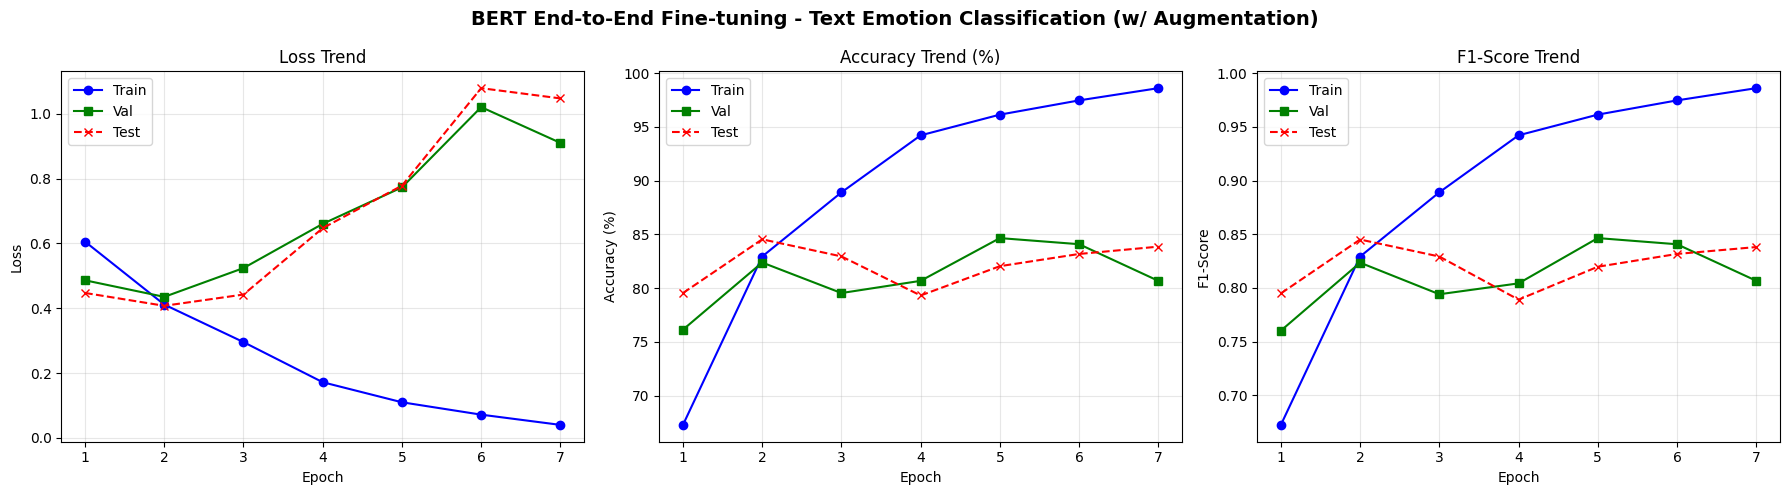

In [ ]:
#동결 6
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertModel
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import nlpaug.augmenter.word as naw
import nltk
from nltk.corpus import wordnet
import warnings
warnings.filterwarnings('ignore')


# 최초 1회 NLTK WordNet 데이터 다운로드 필요
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')    # 에러 해결 핵심!
nltk.download('averaged_perceptron_tagger_eng') # 최신 NLTK 버전 대응용
nltk.download('punkt')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")

# ==========================================
# 1. 데이터 로드 및 전처리
# ==========================================
text_df = pd.read_csv('mosi_text_metadata.csv')
print(f"결측치 제거 전: {len(text_df)}")
text_df = text_df.dropna(subset=['text', 'label'])
print(f"결측치 제거 후: {len(text_df)}")
print(f"레이블 분포:\n{text_df['label'].value_counts()}")

texts = text_df['text'].tolist()
labels = text_df['label'].tolist()

# Train/Val/Test로 분할 (원본 데이터 기준)
tr_texts, te_texts, tr_labels, te_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)
# val 분할
tr_texts, val_texts, tr_labels, val_labels = train_test_split(
    tr_texts, tr_labels, test_size=0.1, random_state=42, stratify=tr_labels
)
print(f"\n증강 전 Train: {len(tr_texts)} | Val: {len(val_texts)} | Test: {len(te_texts)}")

# ==========================================
# [추가] 데이터 증강 (Train Set에만 적용!)
# ==========================================
print("\n데이터 증강 진행 중 (Train 셋에만 적용)...")
# aug_p: 변경 확률(10~20% 권장)
aug_syn = naw.SynonymAug(aug_src='wordnet', aug_p=0.2)

augmented_tr_texts = []
augmented_tr_labels = []

# 원본 Train 데이터도 유지하면서, 증강된 데이터를 추가합니다.
for text, label in zip(tr_texts, tr_labels):
    # 1. 원본 데이터 추가
    augmented_tr_texts.append(text)
    augmented_tr_labels.append(label)

    # 2. 증강 데이터 생성 및 추가 (1배수 증강 예시)
    if isinstance(text, str) and text.strip() != "":
        aug_text = aug_syn.augment(text)
        # nlpaug 버전에 따라 리스트로 반환될 수 있으므로 문자열로 추출
        if isinstance(aug_text, list):
            aug_text = aug_text[0]

        augmented_tr_texts.append(aug_text)
        augmented_tr_labels.append(label)

# 증강된 데이터로 교체
tr_texts = augmented_tr_texts
tr_labels = augmented_tr_labels

print(f"증강 후 Train 데이터 수: {len(tr_texts)}")


# ==========================================
# 2. 데이터셋 및 데이터로더
# ==========================================
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
MAX_TEXT_LEN = 50
BATCH_SIZE = 16



class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts   = texts
        self.labels  = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_loader = DataLoader(TextDataset(tr_texts,  tr_labels,  tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TextDataset(val_texts, val_labels, tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TextDataset(te_texts,  te_labels,  tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 3. 모델 : BERT + projection + 분류기
# ==========================================
class TEXTEncoderWithClassifier(nn.Module):
    def __init__(self, num_classes=2, proj_dim=256, freeze_bert_layers=6):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')

        # BERT 하위 레이어 동결
        for name, param in self.bert.named_parameters():
            layer_num = None
            for part in name.split('.'):
                if part.isdigit():
                    layer_num = int(part)
                    break
            if layer_num is not None and layer_num < freeze_bert_layers:
                param.requires_grad = False

        self.dropout    = nn.Dropout(0.3)
        self.projection = nn.Linear(768, proj_dim)

        # 분류기 헤드
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, input_ids, attention_mask, return_features=False):
        outputs      = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled       = outputs.pooler_output                     # [B, 768]
        features     = self.projection(self.dropout(pooled))  # [B, 256]
        logits       = self.classifier(features)

        if return_features:
            return features
        return logits

# ==========================================
# 4. 학습 설정
# ==========================================
NUM_EPOCHS = 15
NUM_CLASSES = 2

model = TEXTEncoderWithClassifier(num_classes=NUM_CLASSES).to(device)

bert_params       = [p for n, p in model.named_parameters() if 'bert' in n and p.requires_grad]
non_bert_params   = [p for n, p in model.named_parameters() if 'bert' not in n]

optimizer = optim.AdamW([
    {'params': bert_params,     'lr': 1e-5, 'weight_decay': 0.01},
    {'params': non_bert_params, 'lr': 1e-3, 'weight_decay': 0.01}
])
criterion = nn.CrossEntropyLoss()

# ==========================================
# 5. 학습 루프
# ==========================================
def run_epoch(model, loader, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_targets = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            input_ids     = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch  = batch['label'].to(device)

            logits = model(input_ids, attention_mask)
            loss   = criterion(logits, labels_batch)

            if train:
                optimizer.zero_grad()
                loss.backward()
                # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            preds = logits.argmax(1)
            total_loss += loss.item() * labels_batch.size(0)
            correct    += (preds == labels_batch).sum().item()
            total      += labels_batch.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels_batch.cpu().numpy())

    avg_loss = total_loss / total
    acc      = correct / total * 100
    f1       = f1_score(all_targets, all_preds, average='macro')
    return avg_loss, acc, f1

history = {k: [] for k in ['train_loss','val_loss','test_loss',
                             'train_acc', 'val_acc', 'test_acc',
                             'train_f1',  'val_f1',  'test_f1']}

best_val_loss = float('inf')
patience       = 5
patience_count = 0
best_state     = None

print("\n파인튜닝 시작")
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = run_epoch(model, train_loader, optimizer,  train=True)
    vl_loss, vl_acc, vl_f1 = run_epoch(model, val_loader,   train=False)
    te_loss, te_acc, te_f1 = run_epoch(model, test_loader,  train=False)

    for k, v in zip(['train_loss','val_loss','test_loss',
                     'train_acc', 'val_acc', 'test_acc',
                     'train_f1',  'val_f1',  'test_f1'],
                    [tr_loss, vl_loss, te_loss,
                     tr_acc,  vl_acc,  te_acc,
                     tr_f1,   vl_f1,   te_f1]):
        history[k].append(v)

    print(f"Epoch {epoch:2d} | "
          f"Train Acc {tr_acc:.1f}% (F1 {tr_f1:.4f}) | "
          f"Val Acc {vl_acc:.1f}% (F1 {vl_f1:.4f}) | "
          f"Test Acc {te_acc:.1f}% (F1 {te_f1:.4f})")

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_state  = {k: v.clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= patience:
            print(f"\n⏹ Early Stopping at epoch {epoch} (val_loss not improved for {patience} epochs)")
            break

if best_state:
    model.load_state_dict(best_state)
    print(f"✅ 최적 모델 복원 완료 (Best Val Loss: {best_val_loss:.4f})")

te_loss, te_acc, te_f1 = run_epoch(model, test_loader, train=False)
print(f"\n✨ 최종 Test Acc: {te_acc:.1f}% | Test F1: {te_f1:.4f} ✨")

# ==========================================
# 6. 멀티모달 fusion을 위한 특징 추출
# ==========================================
print("\n─── 멀티모달 fusion용 256차원 특징 추출 ───")
# 주의: 전체 특징 추출 시에는 원본 데이터(texts)를 사용해야 인덱스가 맞습니다.
all_dataset = TextDataset(texts, labels, tokenizer, MAX_TEXT_LEN)
all_loader  = DataLoader(all_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
all_features, all_labels_out = [], []
with torch.no_grad():
    for batch in tqdm(all_loader, desc="특징 추출"):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        feats = model(input_ids, attention_mask, return_features=True)
        all_features.append(feats.cpu())
        all_labels_out.append(batch['label'])

X_text = torch.cat(all_features, dim=0)
y_text = torch.cat(all_labels_out, dim=0)

torch.save({'features': X_text, 'labels': y_text}, 'text_features_256(증강+동결6+earlystop).pkl')
print("✅ 텍스트 모달 특징 벡터 저장 완료 (text_features_256.pkl)")
print(f"추출 완료! X_text shape: {X_text.shape}")

# ==========================================
# 7. 시각화
# ==========================================
actual_epochs = len(history['train_loss'])
epochs = range(1, actual_epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs, history['val_loss'],   'g-s', label='Val')
axes[0].plot(epochs, history['test_loss'],  'r--x', label='Test')
axes[0].set_title('Loss Trend'); axes[0].set_ylabel('Loss')

axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train')
axes[1].plot(epochs, history['val_acc'],   'g-s', label='Val')
axes[1].plot(epochs, history['test_acc'],  'r--x', label='Test')
axes[1].set_title('Accuracy Trend (%)'); axes[1].set_ylabel('Accuracy (%)')

axes[2].plot(epochs, history['train_f1'], 'b-o', label='Train')
axes[2].plot(epochs, history['val_f1'],   'g-s', label='Val')
axes[2].plot(epochs, history['test_f1'],  'r--x', label='Test')
axes[2].set_title('F1-Score Trend'); axes[2].set_ylabel('F1-Score')

for ax in axes:
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('BERT End-to-End Fine-tuning - Text Emotion Classification (w/ Augmentation)',
             fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()